<a href="https://colab.research.google.com/github/srishanthdevoju/Celebal_Internship/blob/main/week4_srishanthdevoju.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

np.savez_compressed(
    '/content/drive/MyDrive/cifar10.npz',
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

print("Saved CIFAR-10 to Google Drive")

Mounted at /content/drive
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3510s 21us/step
Saved CIFAR-10 to Google Drive


In [5]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

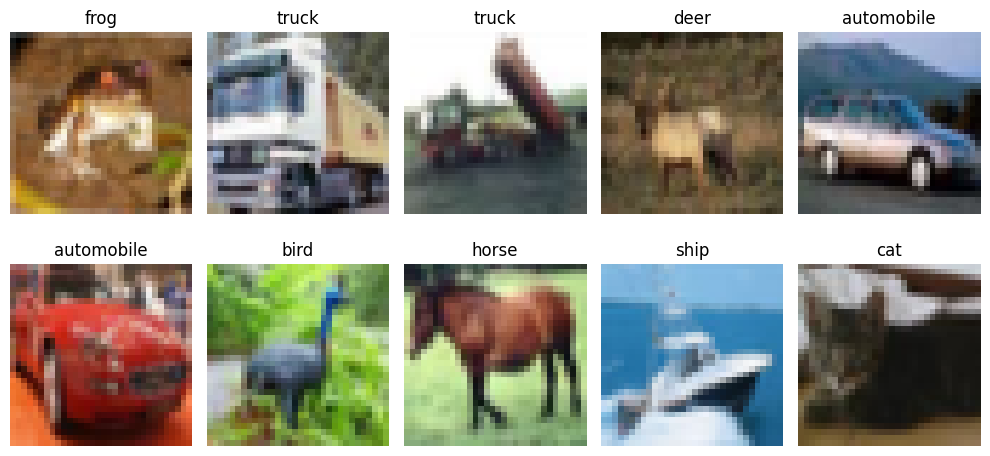

In [89]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.savefig('sampledata.png')
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [7]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [8]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2713 - loss: 1.9936 - val_accuracy: 0.3386 - val_loss: 1.8483
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3182 - loss: 1.8713 - val_accuracy: 0.3482 - val_loss: 1.8140
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3404 - loss: 1.8110 - val_accuracy: 0.3854 - val_loss: 1.7326
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3572 - loss: 1.7743 - val_accuracy: 0.3874 - val_loss: 1.7177
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3667 - loss: 1.7465 - val_accuracy: 0.4022 - val_loss: 1.6766
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3746 - loss: 1.7248 - val_accuracy: 0.3886 - val_loss: 1.7013
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3832 - loss: 1.7087 - val_accuracy: 0.3914 - val_loss: 1.7124
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3903 - loss: 1.6853 - val_accuracy: 0.

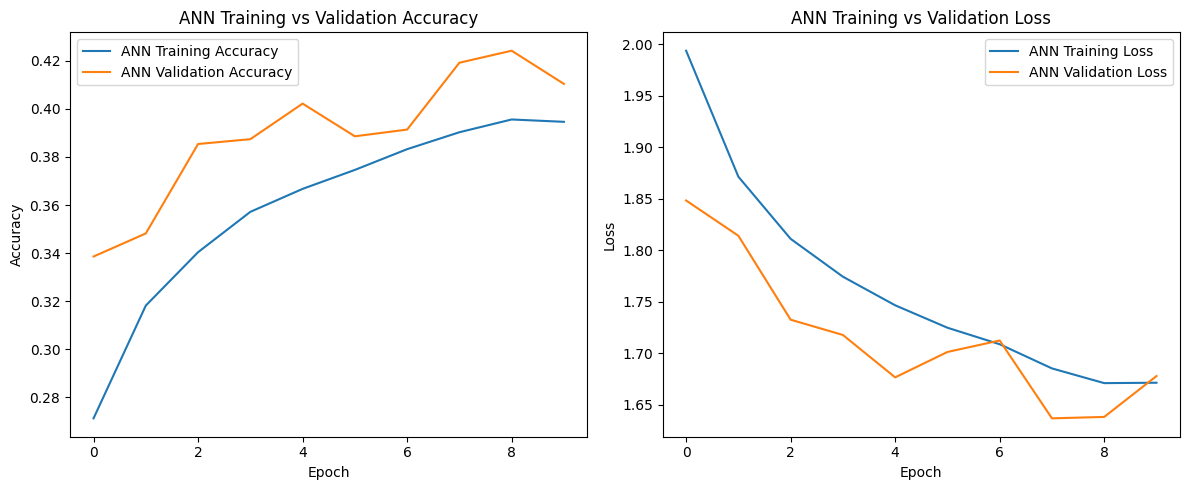

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ann_history.history['accuracy'], label='ANN Training Accuracy')
plt.plot(ann_history.history['val_accuracy'], label='ANN Validation Accuracy')
plt.title('ANN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ann_history.history['loss'], label='ANN Training Loss')
plt.plot(ann_history.history['val_loss'], label='ANN Validation Loss')
plt.title('ANN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_ann_train_val_metrics.png')
plt.show()

In [11]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4170 - loss: 1.6633
ANN Test Accuracy: 0.4169999957084656


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [12]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4655 - loss: 1.4948 - val_accuracy: 0.4966 - val_loss: 1.4739
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6097 - loss: 1.1171 - val_accuracy: 0.5186 - val_loss: 1.4136
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6713 - loss: 0.9459 - val_accuracy: 0.6512 - val_loss: 1.0134
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7112 - loss: 0.8280 - val_accuracy: 0.6798 - val_loss: 0.9324
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7459 - loss: 0.7246 - val_accuracy: 0.6888 - val_loss: 0.9264
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7711 - loss: 0.6527 - val_accuracy: 0.7306 - val_loss: 0.7988
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7965 - loss: 0.5769 - val_accuracy: 0.7248 - val_loss: 0.8453
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8173 - loss: 0.5151 - val_accuracy:

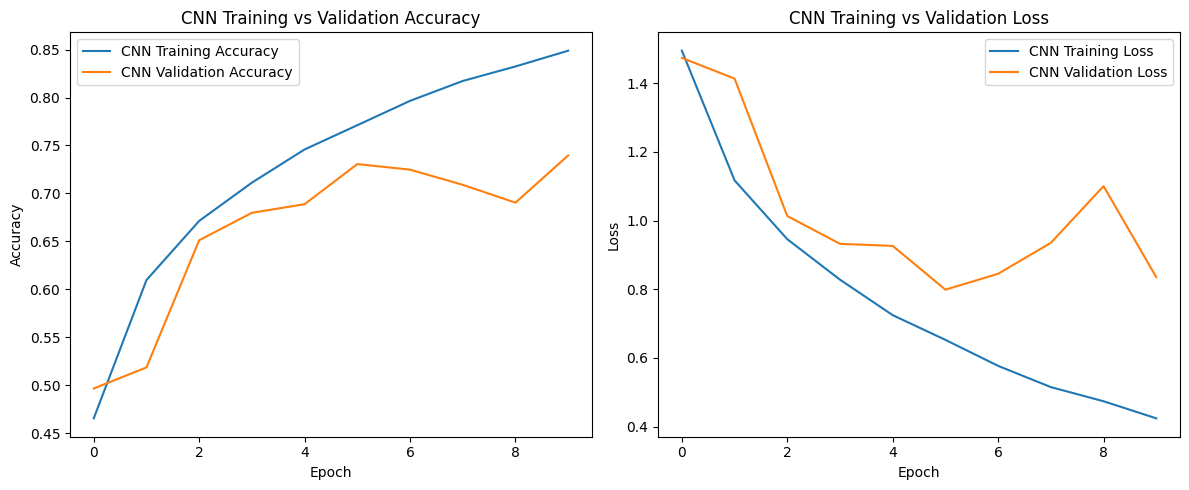

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy')
plt.title('CNN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Training Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss')
plt.title('CNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_cnn_train_val_metrics.png')
plt.show()

In [14]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7301 - loss: 0.8852
CNN Test Accuracy: 0.7300999760627747


## 📈 Compare Learning Curves

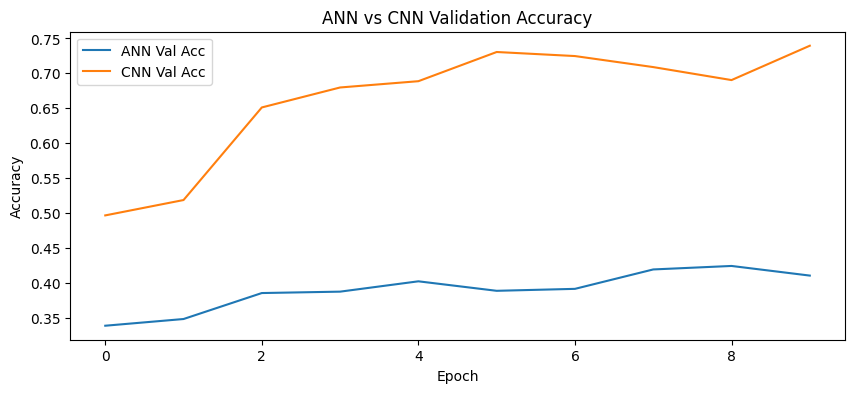

In [15]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [58]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1) # Added width/height shifts
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

In [17]:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.3640 - loss: 1.7354 - val_accuracy: 0.4714 - val_loss: 1.4538
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4598 - loss: 1.5006 - val_accuracy: 0.5156 - val_loss: 1.3235
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4966 - loss: 1.4099 - val_accuracy: 0.5476 - val_loss: 1.2587
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.5187 - loss: 1.3497 - val_accuracy: 0.5704 - val_loss: 1.2057
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5352 - loss: 1.3067 - val_accuracy: 0.5926 - val_loss: 1.1401
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5490 - loss: 1.2747 - val_accuracy: 0.6208 - val_loss: 1.0574
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5579 - loss: 1.2492 - val_accuracy: 0.6062 - val_loss: 1.1016
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5666 - loss: 1.

# 📊 Final Comparison Table

In [18]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4170
1,CNN,0.7301


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## Beginner Task 1: Increase ANN Layers

In [19]:

ann_model_v2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3), # Added new dropout layer
    layers.Dense(128, activation='relu'), # Added new dense layer
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("ANN Model v2 (with increased layers) architecture:")
ann_model_v2.summary()

ANN Model v2 (with increased layers) architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
ann_history_v2 = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2446 - loss: 2.0308 - val_accuracy: 0.2902 - val_loss: 1.9137
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2970 - loss: 1.9078 - val_accuracy: 0.3018 - val_loss: 1.8733
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3128 - loss: 1.8692 - val_accuracy: 0.3528 - val_loss: 1.8051
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3214 - loss: 1.8473 - val_accuracy: 0.3620 - val_loss: 1.7657
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3317 - loss: 1.8184 - val_accuracy: 0.3652 - val_loss: 1.7833
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3383 - loss: 1.8020 - val_accuracy: 0.3674 - val_loss: 1.7799
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3415 - loss: 1.7945 - val_accuracy: 0.3856 - val_loss: 1.7289
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3501 - loss: 1.7763 - val_accuracy: 0.

### ANN Increased Layers Training History (Accuracy and Loss)


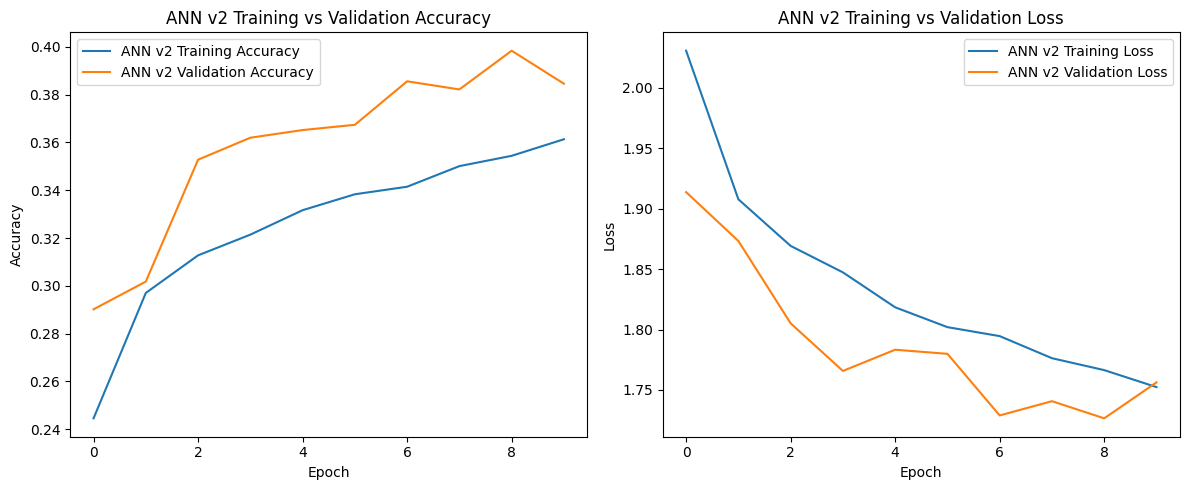

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ann_history_v2.history['accuracy'], label='ANN v2 Training Accuracy')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN v2 Validation Accuracy')
plt.title('ANN v2 Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ann_history_v2.history['loss'], label='ANN v2 Training Loss')
plt.plot(ann_history_v2.history['val_loss'], label='ANN v2 Validation Loss')
plt.title('ANN v2 Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_ann_v2_train_val_metrics.png')
plt.show()

In [22]:
ann_test_loss_v2, ann_test_acc_v2 = ann_model_v2.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy (v2 - Increased Layers):", ann_test_acc_v2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3915 - loss: 1.7393
ANN Test Accuracy (v2 - Increased Layers): 0.39149999618530273


In [23]:
comparison = pd.DataFrame({
    "Model": ["ANN (Original)", "CNN", "ANN (Increased Layers)"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, ann_test_acc_v2]
})
display(comparison)

,Model,Test Accuracy
0,ANN (Original),0.4170
1,CNN,0.7301
2,ANN (Increased Layers),0.3915


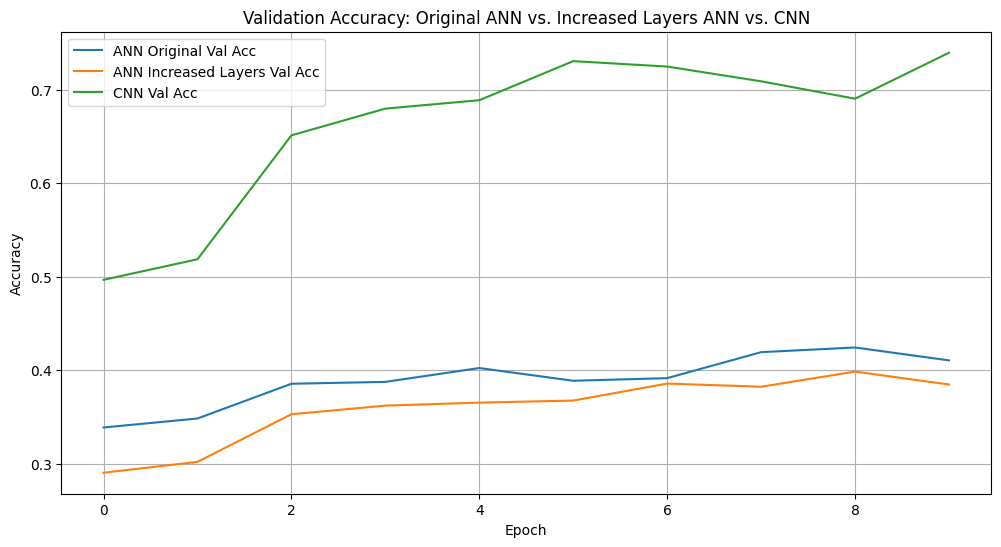

In [24]:
plt.figure(figsize=(12,6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN Increased Layers Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: Original ANN vs. Increased Layers ANN vs. CNN")
plt.legend()
plt.grid(True)
plt.savefig('plot_3_ann_original_vs_increased_layers_vs_cnn.png') # Save the plot
plt.show()

## Beginner Task 2: Change CNN filters from 32→64→128

In [57]:
from tensorflow.keras import regularizers

cnn_model_v2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3), kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model v2 (with increased filters and more dropout) architecture:")
cnn_model_v2.summary()

CNN Model v2 (with increased filters and more dropout) architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,562 (1.86 MB)

 Trainable params: 487,178 (1.86 MB)

 Non-trainable params: 384 (1.50 KB)

In [59]:
cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.4202 - loss: 1.9918 - val_accuracy: 0.4538 - val_loss: 1.9305
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5742 - loss: 1.5079 - val_accuracy: 0.3844 - val_loss: 2.4019
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6446 - loss: 1.3145 - val_accuracy: 0.5962 - val_loss: 1.4489
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6773 - loss: 1.2170 - val_accuracy: 0.6528 - val_loss: 1.2906
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7066 - loss: 1.1488 - val_accuracy: 0.6546 - val_loss: 1.2996
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7237 - loss: 1.1097 - val_accuracy: 0.5994 - val_loss: 1.5876
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7371 - loss: 1.0844 - val_accuracy: 0.7270 - val_loss: 1.1126
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7420 - loss: 1.0716 - val_accuracy: 

### CNN Increased Filters Training History (Accuracy and Loss)


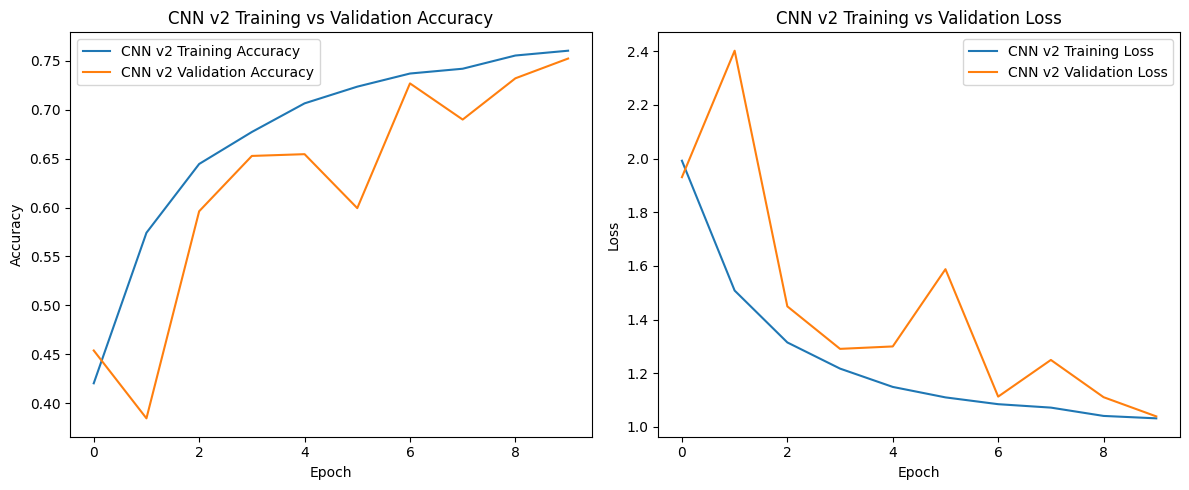

In [60]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history_v2.history['accuracy'], label='CNN v2 Training Accuracy')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN v2 Validation Accuracy')
plt.title('CNN v2 Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_v2.history['loss'], label='CNN v2 Training Loss')
plt.plot(cnn_history_v2.history['val_loss'], label='CNN v2 Validation Loss')
plt.title('CNN v2 Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_cnn_v2_train_val_metrics.png')
plt.show()

In [61]:
cnn_test_loss_v2, cnn_test_acc_v2 = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy (v2 - Increased Filters):", cnn_test_acc_v2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7537 - loss: 1.0501
CNN Test Accuracy (v2 - Increased Filters): 0.7537000179290771


In [62]:
comparison = pd.DataFrame({
    "Model": ["ANN (Original)", "CNN (Original)", "ANN (Increased Layers)", "CNN (Increased Filters)"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, ann_test_acc_v2, cnn_test_acc_v2]
})
display(comparison)

,Model,Test Accuracy
0,ANN (Original),0.4170
1,CNN (Original),0.7301
2,ANN (Increased Layers),0.3915
3,CNN (Increased Filters),0.7537


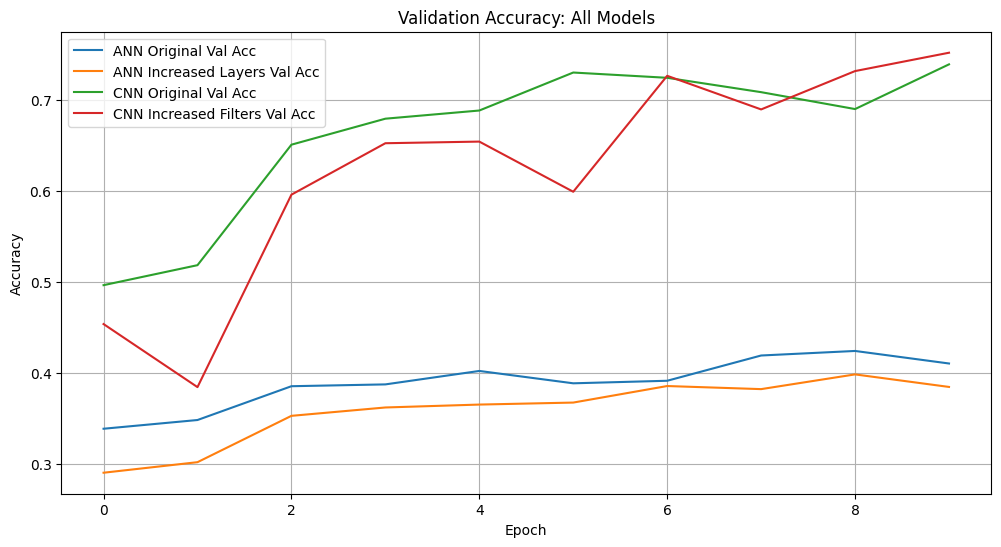

In [63]:
plt.figure(figsize=(12,6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN Increased Layers Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN Increased Filters Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: All Models")
plt.legend()
plt.grid(True)
plt.savefig('plot_4_all_models_increased_filters_val_accuracy.png') # Save the plot
plt.show()

## Beginner Task 3: Increase epochs to 20

In [64]:
cnn_history_v3_epochs20 = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20, # Increased epochs to 20
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7666 - loss: 1.0215 - val_accuracy: 0.6822 - val_loss: 1.2543
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7747 - loss: 1.0022 - val_accuracy: 0.7390 - val_loss: 1.1308
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7767 - loss: 0.9973 - val_accuracy: 0.7268 - val_loss: 1.1608
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7808 - loss: 0.9870 - val_accuracy: 0.7000 - val_loss: 1.2069
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7876 - loss: 0.9786 - val_accuracy: 0.6942 - val_loss: 1.2599
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7844 - loss: 0.9775 - val_accuracy: 0.7530 - val_loss: 1.0934
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7915 - loss: 0.9727 - val_accuracy: 0.7708 - val_loss: 1.0561
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7922 - loss: 0.9688 - val_accuracy: 0

### CNN Increased Filters (20 Epochs) Training History (Accuracy and Loss)

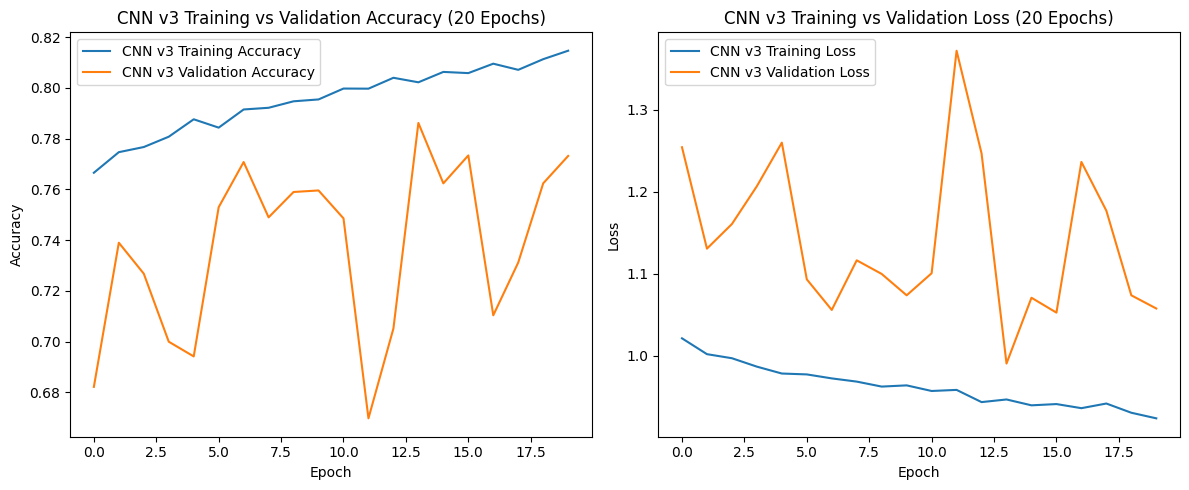

In [65]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history_v3_epochs20.history['accuracy'], label='CNN v3 Training Accuracy')
plt.plot(cnn_history_v3_epochs20.history['val_accuracy'], label='CNN v3 Validation Accuracy')
plt.title('CNN v3 Training vs Validation Accuracy (20 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_v3_epochs20.history['loss'], label='CNN v3 Training Loss')
plt.plot(cnn_history_v3_epochs20.history['val_loss'], label='CNN v3 Validation Loss')
plt.title('CNN v3 Training vs Validation Loss (20 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_cnn_v3_20epochs_train_val_metrics.png')
plt.show()

In [66]:
cnn_test_loss_v3_epochs20, cnn_test_acc_v3_epochs20 = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy (v3 - 20 Epochs):", cnn_test_acc_v3_epochs20)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7631 - loss: 1.0864
CNN Test Accuracy (v3 - 20 Epochs): 0.7631000280380249


In [67]:
comparison = pd.DataFrame({
    "Model": [
        "ANN (Original)",
        "CNN (Original)",
        "ANN (Increased Layers)",
        "CNN (Increased Filters)",
        "CNN (Increased Filters, 20 Epochs)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_test_acc_v2,
        cnn_test_acc_v2,
        cnn_test_acc_v3_epochs20
    ]
})
display(comparison)

,Model,Test Accuracy
0,ANN (Original),0.4170
1,CNN (Original),0.7301
2,ANN (Increased Layers),0.3915
3,CNN (Increased Filters),0.7537
4,"CNN (Increased Filters, 20 Epochs)",0.7631


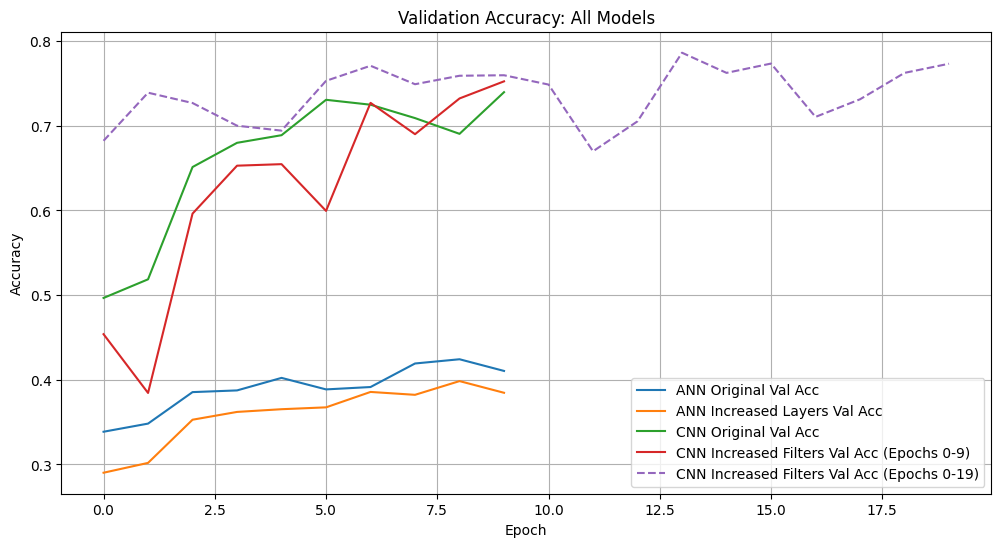

In [68]:
plt.figure(figsize=(12,6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN Increased Layers Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-9)')

# Extend the plot for the new 20-epoch training
plt.plot(cnn_history_v3_epochs20.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-19)', linestyle='--')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: All Models")
plt.legend()
plt.grid(True)
plt.show()

## Beginner Task 4: Add EarlyStopping


In [69]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
cnn_history_v4_early_stopping = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=30,#Set to 30
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8133 - loss: 0.9239 - val_accuracy: 0.7850 - val_loss: 1.0282
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8141 - loss: 0.9239 - val_accuracy: 0.7550 - val_loss: 1.1429
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8150 - loss: 0.9272 - val_accuracy: 0.7758 - val_loss: 1.0323
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8137 - loss: 0.9233 - val_accuracy: 0.7606 - val_loss: 1.1164
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8181 - loss: 0.9149 - val_accuracy: 0.7446 - val_loss: 1.1645
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8155 - loss: 0.9245 - val_accuracy: 0.7734 - val_loss: 1.0706
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


### CNN Early Stopping Training History (Accuracy and Loss)

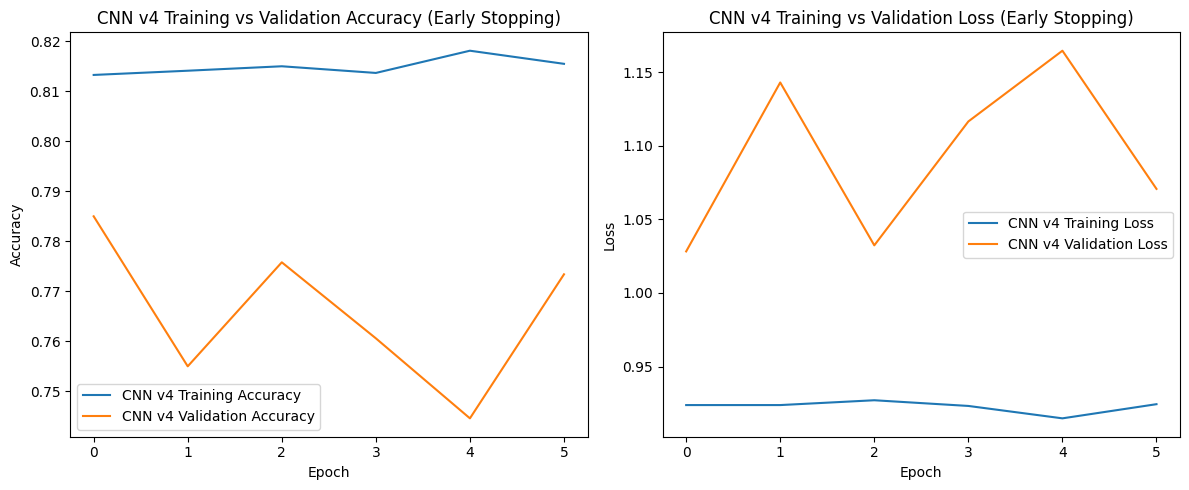

In [70]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history_v4_early_stopping.history['accuracy'], label='CNN v4 Training Accuracy')
plt.plot(cnn_history_v4_early_stopping.history['val_accuracy'], label='CNN v4 Validation Accuracy')
plt.title('CNN v4 Training vs Validation Accuracy (Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_v4_early_stopping.history['loss'], label='CNN v4 Training Loss')
plt.plot(cnn_history_v4_early_stopping.history['val_loss'], label='CNN v4 Validation Loss')
plt.title('CNN v4 Training vs Validation Loss (Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_cnn_v4_early_stopping_train_val_metrics.png')
plt.show()

In [71]:
cnn_test_loss_v4_early_stopping, cnn_test_acc_v4_early_stopping = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy (v4 - Early Stopping):", cnn_test_acc_v4_early_stopping)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7792 - loss: 1.0444
CNN Test Accuracy (v4 - Early Stopping): 0.77920001745224


In [72]:
comparison = pd.DataFrame({
    "Model": [
        "ANN (Original)",
        "CNN (Original)",
        "ANN (Increased Layers)",
        "CNN (Increased Filters)",
        "CNN (Increased Filters, 20 Epochs)",
        "CNN (Early Stopping)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_test_acc_v2,
        cnn_test_acc_v2,
        cnn_test_acc_v3_epochs20,
        cnn_test_acc_v4_early_stopping
    ]
})
display(comparison)

,Model,Test Accuracy
0,ANN (Original),0.4170
1,CNN (Original),0.7301
2,ANN (Increased Layers),0.3915
3,CNN (Increased Filters),0.7537
4,"CNN (Increased Filters, 20 Epochs)",0.7631
5,CNN (Early Stopping),0.7792


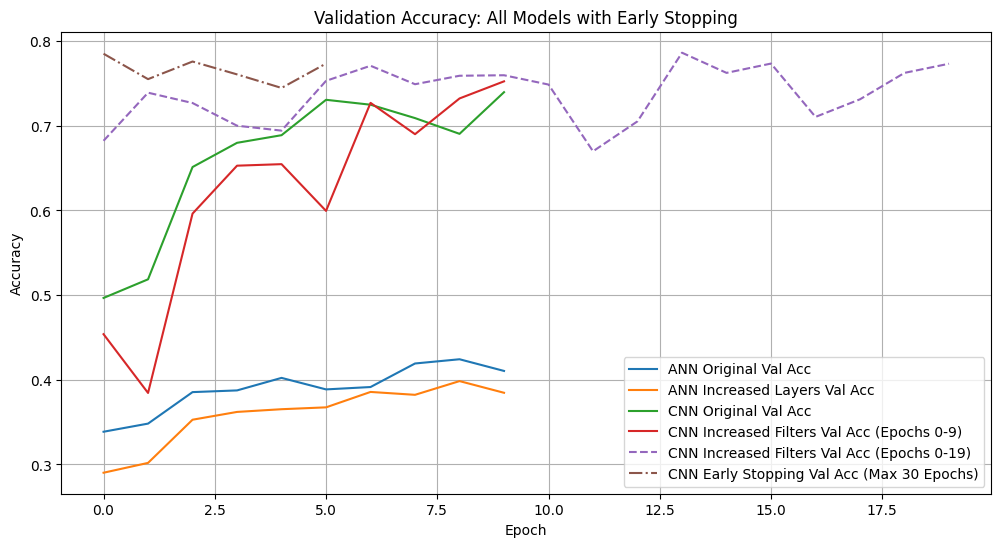

In [73]:
plt.figure(figsize=(12,6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN Increased Layers Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-9)')
plt.plot(cnn_history_v3_epochs20.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-19)', linestyle='--')

plt.plot(cnn_history_v4_early_stopping.history['val_accuracy'], label='CNN Early Stopping Val Acc (Max 30 Epochs)', linestyle='-.')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: All Models with Early Stopping")
plt.legend()
plt.grid(True)
plt.savefig('plot_5_all_models_early_stopping_val_accuracy.png') # Save the plot
plt.show()

## Beginner Task 5: Add data augmentation training

In [80]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

In [83]:
aug_cnn_model = tf.keras.Sequential([
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
aug_cnn_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.3409 - loss: 1.7893 - val_accuracy: 0.4622 - val_loss: 1.4668
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4452 - loss: 1.5220 - val_accuracy: 0.5202 - val_loss: 1.3272
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4895 - loss: 1.4154 - val_accuracy: 0.5312 - val_loss: 1.3149
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5148 - loss: 1.3441 - val_accuracy: 0.5512 - val_loss: 1.2982
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5404 - loss: 1.2859 - val_accuracy: 0.5368 - val_loss: 1.3269
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5560 - loss: 1.2471 - val_accuracy: 0.5996 - val_loss: 1.1725
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5676 - loss: 1.2131 - val_accuracy: 0.6190 - val_loss: 1.1023
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5799 - loss: 1.1877 - val_accur

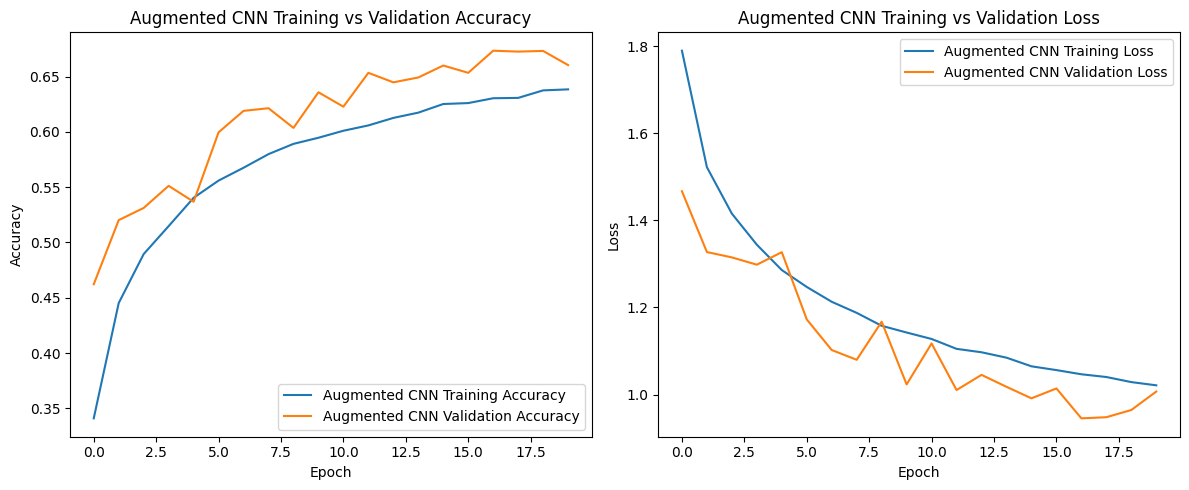

In [85]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(aug_cnn_history.history['accuracy'], label='Augmented CNN Training Accuracy')
plt.plot(aug_cnn_history.history['val_accuracy'], label='Augmented CNN Validation Accuracy')
plt.title('Augmented CNN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(aug_cnn_history.history['loss'], label='Augmented CNN Training Loss')
plt.plot(aug_cnn_history.history['val_loss'], label='Augmented CNN Validation Loss')
plt.title('Augmented CNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_aug_cnn_train_val_metrics.png')
plt.show()

In [86]:
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy (Data Augmentation):", aug_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6564 - loss: 1.0182
CNN Test Accuracy (Data Augmentation): 0.6564000248908997


In [87]:
comparison = pd.DataFrame({
    "Model": [
        "ANN (Original)",
        "CNN (Original)",
        "ANN (Increased Layers)",
        "CNN (Increased Filters)",
        "CNN (Increased Filters, 20 Epochs)",
        "CNN (Early Stopping)",
        "CNN (Data Augmentation)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_test_acc_v2,
        cnn_test_acc_v2,
        cnn_test_acc_v3_epochs20,
        cnn_test_acc_v4_early_stopping,
        aug_cnn_test_acc
    ]
})
display(comparison)

,Model,Test Accuracy
0,ANN (Original),0.4170
1,CNN (Original),0.7301
2,ANN (Increased Layers),0.3915
3,CNN (Increased Filters),0.7537
4,"CNN (Increased Filters, 20 Epochs)",0.7631
5,CNN (Early Stopping),0.7792
6,CNN (Data Augmentation),0.6564


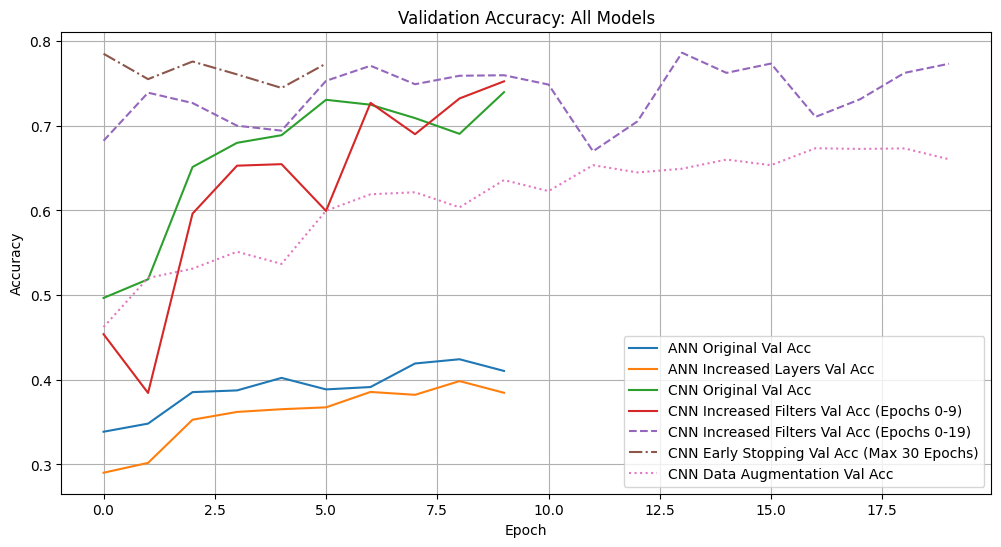

In [88]:
plt.figure(figsize=(12,6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN Increased Layers Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-9)')
plt.plot(cnn_history_v3_epochs20.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-19)', linestyle='--')
plt.plot(cnn_history_v4_early_stopping.history['val_accuracy'], label='CNN Early Stopping Val Acc (Max 30 Epochs)', linestyle='-.')
plt.plot(aug_cnn_history.history['val_accuracy'], label='CNN Data Augmentation Val Acc', linestyle=':')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: All Models")
plt.legend()
plt.grid(True)
plt.savefig('plot_6_all_models_data_augmentation_val_accuracy.png') # Save the plot
plt.show()

This project compared the performance of Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs) on the CIFAR-10 image classification dataset. Images were preprocessed through normalization and multiple model architectures were evaluated.

The ANN models achieved low accuracies of 41.70% and 39.15%, demonstrating their limitations in handling image data. In contrast, CNN-based models performed significantly better due to their ability to learn spatial features from images.

Several improvements were tested on the CNN architecture. Increasing the number of filters and training for more epochs gradually improved performance from 73.01% to 76.31%. The best result was obtained using Early Stopping, achieving a test accuracy of 77.92%, which provided the optimal balance between learning and generalization. Data Augmentation reduced accuracy to 65.64% in this implementation, indicating that the applied transformations may have been too strong or that the model became underfitted.

Overall, the experiment demonstrates that CNNs are highly effective for image classification tasks and significantly outperform traditional ANNs. Early Stopping proved to be the most successful technique for improving model performance while controlling overfitting.

In [90]:
from tensorflow.keras.models import save_model

# Save the cnn_model_v2 (the one with increased filters, regularization, and Early Stopping)
save_model(cnn_model_v2, '/content/cnn_model_v2_final.h5')
print("Saved cnn_model_v2 to /content/cnn_model_v2_final.h5")

# Save the aug_cnn_model
save_model(aug_cnn_model, '/content/aug_cnn_model_final.h5')
print("Saved aug_cnn_model to /content/aug_cnn_model_final.h5")

Saved cnn_model_v2 to /content/cnn_model_v2_final.h5
Saved aug_cnn_model to /content/aug_cnn_model_final.h5


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**